## Visualize the 3 fidelities together

In [1]:
# ## Load and aggregate the three normalized metrics

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/nga_mics")

MARGINAL_PATH = FIDELITY_DIR / "emd_gen_true_normalized.csv"
BIVARIATE_PATH = FIDELITY_DIR / "corrdiff_gen_true_normalized.csv"
JOINT_PATH = FIDELITY_DIR / "joint_emd_gen_true_normalized.csv"

marginal_df = pd.read_csv(MARGINAL_PATH)
bivariate_df = pd.read_csv(BIVARIATE_PATH)
joint_df = pd.read_csv(JOINT_PATH)

print("marginal_df:", marginal_df.shape)
print("bivariate_df:", bivariate_df.shape)
print("joint_df:", joint_df.shape)

display(marginal_df.head())
display(bivariate_df.head())
display(joint_df.head())

marginal_df: (2205, 10)
bivariate_df: (2205, 14)
joint_df: (735, 11)


,model,seed,adm1,variable,emd_distance,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Abia,space_per_person,0.141118,0.029818,0.271733,0.241915,0.460080,0.460080
1,cNF,1,Abia,avg_adult_education,0.052622,0.007789,0.177399,0.169611,0.264329,0.264329
2,cNF,1,Abia,wscore,0.133558,0.033932,0.701260,0.667327,0.149290,0.149290
3,cNF,1,Abuja,space_per_person,0.133682,0.005880,0.249535,0.243655,0.524521,0.524521
4,cNF,1,Abuja,avg_adult_education,0.114629,0.006550,0.303464,0.296914,0.364006,0.364006


,model,seed,adm1,var1,var2,pair,corr_real,corr_syn,corrdiff,corrdiff_ub,corrdiff_lb,denom,corrdiff_norm_raw,corrdiff_norm
0,cNF,1,Abia,space_per_person,avg_adult_education,space_per_person__avg_adult_education,-0.065301,-0.082871,0.017570,0.007744,0.123115,0.115371,0.085171,0.085171
1,cNF,1,Abia,space_per_person,wscore,space_per_person__wscore,0.015967,0.114739,0.098771,0.063011,0.091259,0.028248,1.265953,1.000000
2,cNF,1,Abia,avg_adult_education,wscore,avg_adult_education__wscore,0.588438,0.486581,0.101857,0.020725,0.519987,0.499262,0.162504,0.162504
3,cNF,1,Abuja,space_per_person,avg_adult_education,space_per_person__avg_adult_education,0.129891,-0.108169,0.238060,0.050889,0.187746,0.136856,1.367645,1.000000
4,cNF,1,Abuja,space_per_person,wscore,space_per_person__wscore,0.128178,0.136871,0.008693,0.067629,0.104474,0.036846,-1.599520,0.000000


,model,seed,adm1,joint_emd,n_real,n_syn,emd_ub,emd_lb,denom,emd_norm_raw,emd_norm
0,cNF,1,Abia,0.600840,747,747,0.183293,1.027642,0.844349,0.494519,0.494519
1,cNF,1,Abuja,0.804225,930,930,0.135817,1.317532,1.181715,0.565626,0.565626
2,cNF,1,Adamawa,0.538354,961,961,0.151161,0.852341,0.701180,0.552203,0.552203
3,cNF,1,Akwa Ibom,0.598131,952,952,0.169132,0.747346,0.578214,0.741939,0.741939
4,cNF,1,Anambra,0.430650,731,731,0.178861,1.019609,0.840748,0.299482,0.299482


In [3]:
# Average marginal over variables for each (model, seed, adm1)
marginal_avg = (
    marginal_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        marginal_norm=("emd_norm", "mean")
    )
)

# Average bivariate over pairs for each (model, seed, adm1)
bivariate_avg = (
    bivariate_df
    .groupby(["model", "seed", "adm1"], as_index=False)
    .agg(
        bivariate_norm=("corrdiff_norm", "mean")
    )
)

# Joint is already one value per (model, seed, adm1)
joint_avg = (
    joint_df[["model", "seed", "adm1", "emd_norm"]]
    .rename(columns={"emd_norm": "joint_norm"})
    .copy()
)

display(marginal_avg.head())
display(bivariate_avg.head())
display(joint_avg.head())

,model,seed,adm1,marginal_norm
0,CTGAN,1,Abia,0.179910
1,CTGAN,1,Abuja,0.277160
2,CTGAN,1,Adamawa,0.139917
3,CTGAN,1,Akwa Ibom,0.193198
4,CTGAN,1,Anambra,0.215867


,model,seed,adm1,bivariate_norm
0,CTGAN,1,Abia,0.770453
1,CTGAN,1,Abuja,0.166390
2,CTGAN,1,Adamawa,0.564056
3,CTGAN,1,Akwa Ibom,0.364121
4,CTGAN,1,Anambra,0.023113


,model,seed,adm1,joint_norm
0,cNF,1,Abia,0.494519
1,cNF,1,Abuja,0.565626
2,cNF,1,Adamawa,0.552203
3,cNF,1,Akwa Ibom,0.741939
4,cNF,1,Anambra,0.299482


In [4]:
# Merge the 3 metrics so each row is one (model, seed, adm1)
metrics_3way = (
    marginal_avg
    .merge(bivariate_avg, on=["model", "seed", "adm1"], how="inner")
    .merge(joint_avg, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("metrics_3way shape:", metrics_3way.shape)
display(metrics_3way.head())

metrics_3way shape: (735, 6)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Abia,0.179910,0.770453,0.346539
1,CTGAN,1,Abuja,0.277160,0.166390,0.421936
2,CTGAN,1,Adamawa,0.139917,0.564056,0.364152
3,CTGAN,1,Akwa Ibom,0.193198,0.364121,0.513786
4,CTGAN,1,Anambra,0.215867,0.023113,0.298165


In [5]:
# Optional: save merged table
OUT_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
metrics_3way.to_csv(OUT_PATH, index=False)
print(f"Saved merged table to: {OUT_PATH}")

Saved merged table to: /data/shared/fsibilla/clean_code/Q0/fidelity/nga_mics/merged_marginal_bivariate_joint_normalized.csv


In [6]:
# ## Prepare radar-plot summary
#
# We want:
# - for each model and seed: average across adm1
# - then across seeds: mean
# - and std based on the adm1-level variability after seed averaging

METRIC_COLS = ["marginal_norm", "bivariate_norm", "joint_norm"]

# Mean over adm1 within each seed
seed_level = (
    metrics_3way
    .groupby(["model", "seed"], as_index=False)[METRIC_COLS]
    .mean()
)

display(seed_level.head())

,model,seed,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,0.193212,0.492924,0.459924
1,CTGAN,2,0.150666,0.568885,0.401292
2,CTGAN,3,0.151176,0.402445,0.418978
3,CTGAN,4,0.162744,0.533683,0.399093
4,CTGAN,5,0.195943,0.420665,0.470153


In [7]:
# Mean and std across seeds for the central line
model_mean_std = (
    seed_level
    .groupby("model", as_index=False)
    .agg(
        marginal_mean=("marginal_norm", "mean"),
        marginal_std_seed=("marginal_norm", "std"),
        bivariate_mean=("bivariate_norm", "mean"),
        bivariate_std_seed=("bivariate_norm", "std"),
        joint_mean=("joint_norm", "mean"),
        joint_std_seed=("joint_norm", "std"),
    )
)

model_mean_std = model_mean_std.fillna(0.0)
display(model_mean_std)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed
0,CTGAN,0.170748,0.022304,0.483720,0.071441,0.429888,0.033198
1,NF,0.089237,0.014030,0.369963,0.053729,0.249671,0.040364
2,TVAE,0.268294,0.053568,0.434051,0.046841,0.528145,0.083816
3,cNF,0.245394,0.037008,0.420379,0.046094,0.522246,0.061645


In [8]:
# Std over adm1:
# first average across seeds for each (model, adm1), then compute std across adm1

adm1_level = (
    metrics_3way
    .groupby(["model", "adm1"], as_index=False)[METRIC_COLS]
    .mean()
)

model_adm1_std = (
    adm1_level
    .groupby("model", as_index=False)
    .agg(
        marginal_std_adm1=("marginal_norm", "std"),
        bivariate_std_adm1=("bivariate_norm", "std"),
        joint_std_adm1=("joint_norm", "std"),
    )
)

model_adm1_std = model_adm1_std.fillna(0.0)
display(model_adm1_std)

,model,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.028177,0.103356,0.146353
1,NF,0.026552,0.102227,0.112894
2,TVAE,0.115848,0.106297,0.172188
3,cNF,0.077356,0.102529,0.192696


In [9]:
# Final table for plotting
radar_df = (
    model_mean_std
    .merge(model_adm1_std, on="model", how="left")
    .fillna(0.0)
)

display(radar_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.170748,0.022304,0.483720,0.071441,0.429888,0.033198,0.028177,0.103356,0.146353
1,NF,0.089237,0.014030,0.369963,0.053729,0.249671,0.040364,0.026552,0.102227,0.112894
2,TVAE,0.268294,0.053568,0.434051,0.046841,0.528145,0.083816,0.115848,0.106297,0.172188
3,cNF,0.245394,0.037008,0.420379,0.046094,0.522246,0.061645,0.077356,0.102529,0.192696


In [10]:
# ## Spider / radar plot

MODEL_ORDER = ["cNF", #"NF", 
"TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in radar_df["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    "NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

AXES_LABELS = ["Marginal", "Bivariate", "Joint"]
N_AXES = len(AXES_LABELS)

angles = np.linspace(0, 2 * np.pi, N_AXES, endpoint=False).tolist()
angles += angles[:1]  # close polygon

In [11]:
def close_vals(vals):
    vals = list(vals)
    return vals + vals[:1]

In [12]:
# Convert normalized errors into normalized fidelity scores
radar_score_df = radar_df.copy()

for col in [
    "marginal_mean", "bivariate_mean", "joint_mean",
]:
    radar_score_df[col] = 1.0 - radar_score_df[col]

display(radar_score_df)

,model,marginal_mean,marginal_std_seed,bivariate_mean,bivariate_std_seed,joint_mean,joint_std_seed,marginal_std_adm1,bivariate_std_adm1,joint_std_adm1
0,CTGAN,0.829252,0.022304,0.516280,0.071441,0.570112,0.033198,0.028177,0.103356,0.146353
1,NF,0.910763,0.014030,0.630037,0.053729,0.750329,0.040364,0.026552,0.102227,0.112894
2,TVAE,0.731706,0.053568,0.565949,0.046841,0.471855,0.083816,0.115848,0.106297,0.172188
3,cNF,0.754606,0.037008,0.579621,0.046094,0.477754,0.061645,0.077356,0.102529,0.192696


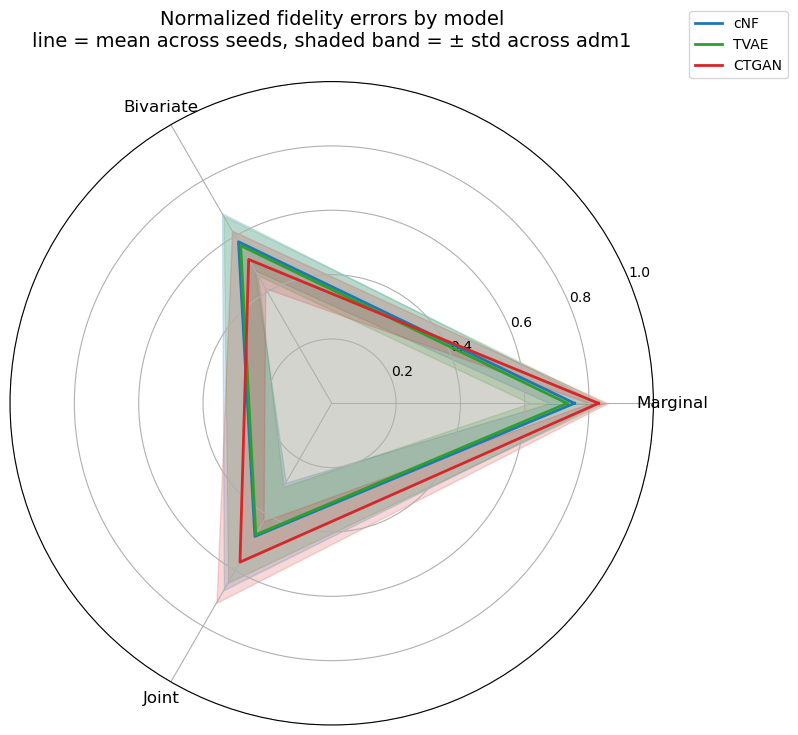

In [13]:
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for model in MODEL_ORDER:
    row = radar_score_df.loc[radar_score_df["model"] == model]
    if row.empty:
        continue
    row = row.iloc[0]

    means = [
        row["marginal_mean"],
        row["bivariate_mean"],
        row["joint_mean"],
    ]

    stds_adm1 = [
        row["marginal_std_adm1"],
        row["bivariate_std_adm1"],
        row["joint_std_adm1"],
    ]

    lower = np.clip(np.array(means) - np.array(stds_adm1), 0, 1)
    upper = np.clip(np.array(means) + np.array(stds_adm1), 0, 1)

    means_c = close_vals(means)
    lower_c = close_vals(lower)
    upper_c = close_vals(upper)

    color = MODEL_COLORS.get(model, "gray")

    ax.plot(
        angles,
        means_c,
        color=color,
        linewidth=2,
        label=model,
    )

    ax.fill(
        angles,
        means_c,
        color=color,
        alpha=0.10,
    )

    ax.fill_between(
        angles,
        lower_c,
        upper_c,
        color=color,
        alpha=0.18,
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(AXES_LABELS, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"])
ax.set_title(
    "Normalized fidelity errors by model\nline = mean across seeds, shaded band = ± std across adm1",
    pad=25,
    fontsize=14
)
ax.legend(loc="upper right", bbox_to_anchor=(1.22, 1.12))

plt.tight_layout()
plt.show()

## Look at originality too

In [14]:
# ## Load fidelity + recall

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
FIDELITY_DIR = Path("/data/shared/fsibilla/clean_code/Q0/fidelity/nga_mics")
RECALL_DIR = Path("/data/shared/fsibilla/clean_code/Q0/recall/nga_mics")

FIDELITY_3WAY_PATH = FIDELITY_DIR / "merged_marginal_bivariate_joint_normalized.csv"
RECALL_PATH = RECALL_DIR / "recall_gen_true_by_adm1.csv"

fidelity_3way = pd.read_csv(FIDELITY_3WAY_PATH)
recall_df = pd.read_csv(RECALL_PATH)

print("fidelity_3way:", fidelity_3way.shape)
print("recall_df:", recall_df.shape)

display(fidelity_3way.head())
display(recall_df.head())

fidelity_3way: (735, 6)
recall_df: (735, 8)


,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm
0,CTGAN,1,Abia,0.179910,0.770453,0.346539
1,CTGAN,1,Abuja,0.277160,0.166390,0.421936
2,CTGAN,1,Adamawa,0.139917,0.564056,0.364152
3,CTGAN,1,Akwa Ibom,0.193198,0.364121,0.513786
4,CTGAN,1,Anambra,0.215867,0.023113,0.298165


,model,seed,adm1,recall,matched_real,n_real,n_syn,radius
0,cNF,1,Abia,0.975904,729,747,747,0.5
1,cNF,1,Abuja,0.983871,915,930,930,0.5
2,cNF,1,Adamawa,0.986472,948,961,961,0.5
3,cNF,1,Akwa Ibom,0.990546,943,952,952,0.5
4,cNF,1,Anambra,0.956224,699,731,731,0.5


In [16]:
# Average the 3 fidelity metrics into one fidelity score (still an error, so lower is better)
fidelity_3way = fidelity_3way.copy()

fidelity_3way["fidelity_mean"] = fidelity_3way[
    ["marginal_norm", "bivariate_norm", "joint_norm"]
].mean(axis=1)

display(fidelity_3way.head())

,model,seed,adm1,marginal_norm,bivariate_norm,joint_norm,fidelity_mean
0,CTGAN,1,Abia,0.179910,0.770453,0.346539,0.432301
1,CTGAN,1,Abuja,0.277160,0.166390,0.421936,0.288495
2,CTGAN,1,Adamawa,0.139917,0.564056,0.364152,0.356042
3,CTGAN,1,Akwa Ibom,0.193198,0.364121,0.513786,0.357035
4,CTGAN,1,Anambra,0.215867,0.023113,0.298165,0.179048


In [17]:
# Keep only the columns needed for the merge
fidelity_for_merge = fidelity_3way[
    ["model", "seed", "adm1", "fidelity_mean"]
].copy()

recall_for_merge = recall_df[
    ["model", "seed", "adm1", "recall"]
].copy()

plot_source = (
    fidelity_for_merge
    .merge(recall_for_merge, on=["model", "seed", "adm1"], how="inner")
    .copy()
)

print("plot_source shape:", plot_source.shape)
display(plot_source.head())

plot_source shape: (735, 5)


,model,seed,adm1,fidelity_mean,recall
0,CTGAN,1,Abia,0.432301,0.957162
1,CTGAN,1,Abuja,0.288495,0.961290
2,CTGAN,1,Adamawa,0.356042,0.966701
3,CTGAN,1,Akwa Ibom,0.357035,0.977941
4,CTGAN,1,Anambra,0.179048,0.941176


In [18]:
# One scatter point per model with x/y std dev error bars
model_summary = (
    plot_source
    .groupby("model", as_index=False)
    .agg(
        recall_mean=("recall", "mean"),
        recall_std=("recall", "std"),
        fidelity_mean=("fidelity_mean", "mean"),
        fidelity_std=("fidelity_mean", "std"),
        n_rows=("recall", "count"),
    )
)

model_summary["recall_std"] = model_summary["recall_std"].fillna(0.0)
model_summary["fidelity_std"] = model_summary["fidelity_std"].fillna(0.0)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,CTGAN,0.973867,0.010837,0.361452,0.103051,185
1,NF,0.981780,0.008347,0.236290,0.106958,185
2,TVAE,0.910246,0.193557,0.411790,0.176394,180
3,cNF,0.981116,0.011522,0.396006,0.122338,185


In [19]:
MODEL_ORDER = ["cNF", #"NF",
 "TVAE", "CTGAN"]
MODEL_ORDER = [m for m in MODEL_ORDER if m in model_summary["model"].unique()]

MODEL_COLORS = {
    "cNF": "tab:blue",
    #"NF": "tab:orange",
    "TVAE": "tab:green",
    "CTGAN": "tab:red",
}

model_summary = (
    model_summary
    .set_index("model")
    .loc[MODEL_ORDER]
    .reset_index()
)

display(model_summary)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows
0,cNF,0.981116,0.011522,0.396006,0.122338,185
1,TVAE,0.910246,0.193557,0.411790,0.176394,180
2,CTGAN,0.973867,0.010837,0.361452,0.103051,185


In [20]:
model_summary_plot = model_summary.copy()
model_summary_plot["fidelity_score"] = 1.0 - model_summary_plot["fidelity_mean"]

display(model_summary_plot)

,model,recall_mean,recall_std,fidelity_mean,fidelity_std,n_rows,fidelity_score
0,cNF,0.981116,0.011522,0.396006,0.122338,185,0.603994
1,TVAE,0.910246,0.193557,0.411790,0.176394,180,0.588210
2,CTGAN,0.973867,0.010837,0.361452,0.103051,185,0.638548


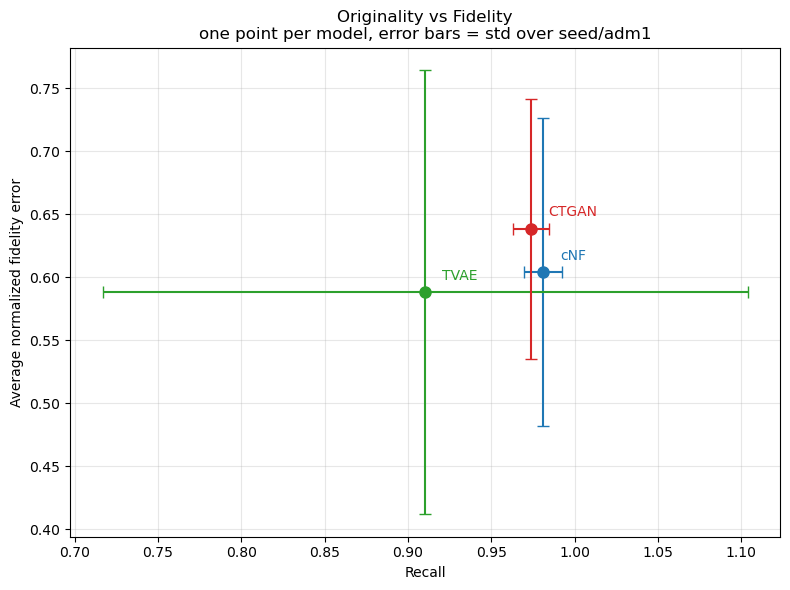

In [21]:
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in model_summary_plot.iterrows():
    model = row["model"]
    x = row["recall_mean"]
    y = row["fidelity_score"]
    xerr = row["recall_std"]
    yerr = row["fidelity_std"]
    color = MODEL_COLORS.get(model, "gray")

    ax.errorbar(
        x,
        y,
        xerr=xerr,
        yerr=yerr,
        fmt="o",
        capsize=4,
        markersize=8,
        color=color,
        ecolor=color,
        elinewidth=1.5,
        label=model,
    )

    ax.text(
        x + 0.01,
        y + 0.01,
        model,
        fontsize=10,
        color=color,
    )

ax.set_xlabel("Recall")
ax.set_ylabel("Average normalized fidelity error")
ax.set_title("Originality vs Fidelity\none point per model, error bars = std over seed/adm1")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()